# Fixed income sleeve — stratégie unique à intégrer

Ce notebook garde uniquement la stratégie retenue pour l’intégration cross-asset : **Combo_Global_50_50 en rebalancement trimestriel**, avec **coûts différenciés** (**10 bps one-way sur Rates**, **50 bps one-way sur Credit**). Le but est de produire une série de performance nette et une matrice de poids mensuels, sans conserver les variantes de recherche.

Les fichiers d’entrée doivent être dans le même dossier que le notebook : `01_universe_returns_clean.xlsx`, `02_signals_clean.xlsx`, `04_asset_metadata.xlsx`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Fichiers d'entrée
RETURNS_FILE = "01_universe_returns_clean.xlsx"
SIGNALS_FILE = "02_signals_clean.xlsx"
META_FILE    = "04_asset_metadata.xlsx"

# Paramètres de la stratégie
RATES_TC_BPS = 10.0
CREDIT_TC_BPS = 50.0
MIN_ASSETS = 6
REBAL_FREQ = "Q"   # "Q" = trimestriel
SPLIT_DATE = "2020-12-31"


In [2]:
# Chargement et mise en forme
returns = pd.read_excel(RETURNS_FILE)
signals = pd.read_excel(SIGNALS_FILE)
meta = pd.read_excel(META_FILE)

returns["Dates"] = pd.to_datetime(returns["Dates"])
signals["Dates"] = pd.to_datetime(signals["Dates"])

returns = returns.set_index("Dates").sort_index().apply(pd.to_numeric, errors="coerce")
signals = signals.set_index("Dates").sort_index().apply(pd.to_numeric, errors="coerce")

# Restriction à l'univers déclaré dans les métadonnées
assets = meta["asset"].tolist()
returns = returns.reindex(columns=assets)

display(meta)
display(returns.head())
display(signals.head())


,asset,bucket,subgroup,label,level_col,breakeven_col,carry_col
0,BCEY4T Index,Rates,Anglophone,Canada,GCAN10YR Index,NaN,GCAN10YR Index
1,BCEG9T Index,Rates,Core Europe,Germany,GDBR10 Index,DEGGBE10 Index,GDBR10 Index
2,H12823GB Index,Rates,Anglophone,UK,GUKG10 Index,UKGGBE10 Index,GUKG10 Index
3,SPFIJ1BP Index,Rates,Defensive/APAC,Japan,GJGB10 Index,NaN,GJGB10 Index
4,H01661US Index,Rates,Anglophone,US,USGG10YR Index,USGGBE10 Index,USGG10YR Index
5,I01682AU Index,Rates,Anglophone,Australia,GACGB10 Index,NaN,GACGB10 Index
6,H28054US Index,Rates,Defensive/APAC,Switzerland,GTCHF10YR Govt,NaN,GTCHF10YR Govt
7,BCEW9T Index,Rates,Core Europe,France,GFRN 10 Index,FRGGBE10 Index,GFRN 10 Index
8,BCEF9T Index,Rates,Core Europe,Sweden,GSGB10YR Index,SKGGBE10 Index,GSGB10YR Index
9,BCEI9T Index,Rates,Peripheral Europe,Italy,GBTPGR10 Index,GILGBE10 Index,GBTPGR10 Index


,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
1990-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-28,NaN,NaN,NaN,NaN,-0.037102,-0.015003,NaN,NaN,NaN,NaN,NaN,0.002901,NaN,-0.020648,NaN
1990-03-30,NaN,NaN,NaN,NaN,-0.022502,0.001806,NaN,NaN,NaN,NaN,NaN,0.000912,NaN,0.026236,NaN
1990-04-30,NaN,NaN,NaN,NaN,-0.019260,-0.007248,NaN,NaN,NaN,NaN,NaN,-0.010425,NaN,-0.001691,NaN
1990-05-31,NaN,NaN,NaN,NaN,0.044137,0.024898,NaN,NaN,NaN,NaN,NaN,0.032347,NaN,0.019296,NaN


,GACGB10 Index,GBTPGR10 Index,GCAN10YR Index,GDBR10 Index,GFRN 10 Index,GJGB10 Index,GSGB10YR Index,GSPG10YR Index,GTCHF10YR Govt,GUKG10 Index,...,USGG10YR Index,DEGGBE10 Index,ER00,FRGGBE10 Index,LF98OAS Index,LUACOAS Index,UKGGBE10 Index,USGGBE10 Index,GILGBE10 Index,SKGGBE10 Index
Dates,,,,,,,,,,,,,,,,,,,,,
1990-01-31,12.71,NaN,9.940,7.648,9.716,6.76,NaN,NaN,NaN,10.94,...,8.418,NaN,NaN,NaN,NaN,0.95,NaN,NaN,NaN,NaN
1990-02-28,13.30,NaN,10.644,8.625,10.180,7.13,NaN,NaN,NaN,11.44,...,8.515,NaN,NaN,NaN,NaN,0.92,NaN,NaN,NaN,NaN
1990-03-30,13.45,NaN,11.137,8.405,9.584,7.45,NaN,NaN,NaN,12.12,...,8.628,NaN,NaN,NaN,NaN,0.91,NaN,NaN,NaN,NaN
1990-04-30,13.80,NaN,11.598,8.813,9.643,6.86,NaN,NaN,NaN,12.83,...,9.022,NaN,NaN,NaN,NaN,0.91,NaN,NaN,NaN,NaN
1990-05-31,13.50,NaN,10.805,8.791,9.678,6.34,NaN,NaN,NaN,11.81,...,8.599,NaN,NaN,NaN,NaN,0.87,NaN,NaN,NaN,NaN


Le signal final est construit en deux étages. D’abord, on calcule une jambe **value globale 50/50** : 50% de value cross-sectionnelle bucketisée et 50% de value temporelle par actif. Ensuite, on combine cette value globale avec le **momentum 12-1** à pondérations égales. On obtient ainsi le signal **Combo_Global_50_50** qui a été retenu dans les tests précédents.

In [3]:
def pick_value_series(row: pd.Series, signal_df: pd.DataFrame) -> pd.Series:
    level_col = row.get("level_col")
    be_col    = row.get("breakeven_col")
    carry_col = row.get("carry_col")

    has_level = pd.notna(level_col) and level_col in signal_df.columns
    has_be    = pd.notna(be_col) and be_col in signal_df.columns
    has_carry = pd.notna(carry_col) and carry_col in signal_df.columns

    if has_level and has_be:
        return signal_df[level_col] - signal_df[be_col]  # real yield proxy
    elif has_level:
        return signal_df[level_col]                      # nominal yield proxy
    elif has_carry:
        return signal_df[carry_col]                     # spread / OAS / CDS proxy
    else:
        return pd.Series(index=signal_df.index, dtype=float)

def bucket_cross_sectional_zscore(df: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    asset_to_bucket = meta.set_index("asset")["bucket"].to_dict()
    bucket_series = pd.Series({c: asset_to_bucket.get(c) for c in df.columns})
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)

    for bucket in bucket_series.dropna().unique():
        cols = bucket_series.index[bucket_series == bucket].tolist()
        sub = df[cols]

        def _z(row: pd.Series) -> pd.Series:
            valid = row.dropna()
            if len(valid) < 2:
                return row * np.nan
            sigma = valid.std(ddof=0)
            if sigma == 0 or np.isnan(sigma):
                return row * np.nan
            return (row - valid.mean()) / sigma

        out[cols] = sub.apply(_z, axis=1)

    return out

def rolling_timeseries_zscore(df: pd.DataFrame, window: int = 60, min_periods: int = 36) -> pd.DataFrame:
    rolling_mean = df.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = df.rolling(window=window, min_periods=min_periods).std(ddof=0)
    return ((df - rolling_mean) / rolling_std.replace(0, np.nan)).shift(1)

# Value brute par actif
value_raw = pd.DataFrame(index=signals.index)
for _, row in meta.iterrows():
    value_raw[row["asset"]] = pick_value_series(row, signals)

# Value cross-sectionnelle par bucket (laggée d'1 mois)
value_cs = bucket_cross_sectional_zscore(value_raw, meta).shift(1)

# Value temporelle (z-score roulant 5 ans, laggé)
value_ts = rolling_timeseries_zscore(value_raw, window=60, min_periods=36)

# Value globale 50/50
value_global = 0.5 * value_cs + 0.5 * value_ts

# Momentum 12-1, standardisé par bucket
momentum_raw = (1 + returns.shift(1)).rolling(11).apply(np.prod, raw=True) - 1
momentum_signal = bucket_cross_sectional_zscore(momentum_raw, meta)

# Signal retenu
combo_global_50_50 = 0.5 * value_global + 0.5 * momentum_signal

display(combo_global_50_50.tail())


,BCEY4T Index,BCEG9T Index,H12823GB Index,SPFIJ1BP Index,H01661US Index,I01682AU Index,H28054US Index,BCEW9T Index,BCEF9T Index,BCEI9T Index,H08282US Index,LUACTRUU Index,LECPTREU Index,LF98TRUU Index,LP01TREU Index
Dates,,,,,,,,,,,,,,,
2025-10-31,0.773220,-0.236043,0.394482,-0.685141,0.485440,1.182722,-0.049873,-0.225900,-0.165026,0.312824,0.861735,-0.416082,-0.403041,0.275404,-0.503762
2025-11-28,0.809262,-0.444417,0.488850,-0.536002,0.571133,1.122503,-0.133581,-0.288753,-0.227793,0.129412,0.875019,-0.389613,-0.439905,0.311805,-0.431421
2025-12-31,1.180252,-0.305378,0.517657,-0.642459,0.473177,0.856634,-0.195695,-0.131740,0.028270,0.244282,0.407094,0.070464,-0.372067,0.085034,-0.801722
2026-01-30,1.251338,-0.193244,0.578170,-0.550744,0.231329,0.880872,-0.065532,-0.150376,0.034124,0.345805,0.478472,0.042393,-0.472786,0.060840,-0.714275
2026-02-27,0.837218,-0.237156,0.526826,-0.531579,0.104070,0.745563,0.145953,-0.137491,0.095541,0.322429,0.705664,-0.318352,-0.390093,0.313941,-0.706339


Le portefeuille est long/short, égal pondéré au sein des deux jambes, avec sélection par terciles sur l’univers disponible à chaque date. Le rebalancement est **trimestriel**. Les coûts de transaction sont appliqués sur le notionnel effectivement échangé.

In [4]:
def rebalance_mask(index: pd.DatetimeIndex, freq: str = "Q") -> pd.Series:
    idx = pd.DatetimeIndex(index)
    freq = freq.upper()

    if freq == "M":
        return pd.Series(True, index=idx)
    if freq == "Q":
        periods = pd.Series(idx.to_period("Q"), index=idx)
        return periods.ne(periods.shift(1)).fillna(True)
    raise ValueError("freq doit être 'M' ou 'Q'")

def long_short_tercile_positions(signal: pd.DataFrame,
                                 returns: pd.DataFrame,
                                 min_assets: int = 6,
                                 freq: str = "Q") -> pd.DataFrame:
    idx = returns.index
    cols = returns.columns
    weights = pd.DataFrame(0.0, index=idx, columns=cols)

    do_rebal = rebalance_mask(idx, freq=freq)
    current_w = pd.Series(0.0, index=cols)

    for dt in idx:
        if do_rebal.loc[dt]:
            s = signal.loc[dt].dropna()
            r = returns.loc[dt].dropna()

            common = s.index.intersection(r.index)
            s = s.loc[common]

            if len(common) >= min_assets:
                ranks = s.rank(method="first")
                n = len(s)

                long_idx = s.index[ranks > 2 * n / 3]
                short_idx = s.index[ranks <= n / 3]

                current_w = pd.Series(0.0, index=cols)
                if len(long_idx) > 0:
                    current_w.loc[long_idx] = 1.0 / len(long_idx)
                if len(short_idx) > 0:
                    current_w.loc[short_idx] = -1.0 / len(short_idx)
            else:
                current_w = pd.Series(0.0, index=cols)

        weights.loc[dt] = current_w

    return weights

def ann_return(monthly_returns: pd.Series) -> float:
    x = monthly_returns.dropna()
    if len(x) == 0:
        return np.nan
    return (1 + x).prod() ** (12 / len(x)) - 1

def ann_vol(monthly_returns: pd.Series) -> float:
    x = monthly_returns.dropna()
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1) * np.sqrt(12)

def sharpe_ratio(monthly_returns: pd.Series) -> float:
    r = ann_return(monthly_returns)
    v = ann_vol(monthly_returns)
    return np.nan if pd.isna(r) or pd.isna(v) or v == 0 else r / v

def max_drawdown(monthly_returns: pd.Series) -> float:
    x = monthly_returns.dropna()
    if len(x) == 0:
        return np.nan
    nav = (1 + x).cumprod()
    return (nav / nav.cummax() - 1).min()

def summary_stats(monthly_returns: pd.Series,
                  monthly_tc: pd.Series | None = None,
                  turnover: pd.Series | None = None) -> pd.Series:
    x = monthly_returns.dropna()
    return pd.Series({
        "n_months": len(x),
        "ann_return": ann_return(x),
        "ann_vol": ann_vol(x),
        "sharpe": sharpe_ratio(x),
        "max_drawdown": max_drawdown(x),
        "hit_ratio": (x > 0).mean() if len(x) else np.nan,
        "avg_monthly_turnover": turnover.mean() if turnover is not None else np.nan,
        "ann_turnover": turnover.mean() * 12 if turnover is not None else np.nan,
        "avg_monthly_tc": monthly_tc.mean() if monthly_tc is not None else np.nan,
    })

def split_stats(monthly_returns: pd.Series, split_date: str, monthly_tc=None, turnover=None) -> pd.DataFrame:
    split_date = pd.Timestamp(split_date)
    windows = {
        "full_sample": monthly_returns,
        "through_2020": monthly_returns.loc[monthly_returns.index <= split_date],
        "2021_2026": monthly_returns.loc[monthly_returns.index > split_date],
    }
    rows = []
    for name, s in windows.items():
        tc = monthly_tc.loc[s.index] if monthly_tc is not None else None
        to = turnover.loc[s.index] if turnover is not None else None
        row = summary_stats(s, tc, to)
        row["window"] = name
        rows.append(row)
    return pd.DataFrame(rows).set_index("window")

asset_cost_bps = meta.set_index("asset")["bucket"].map({"Rates": RATES_TC_BPS, "Credit": CREDIT_TC_BPS}).astype(float)
asset_cost = asset_cost_bps / 10000.0

weights = long_short_tercile_positions(combo_global_50_50, returns, min_assets=MIN_ASSETS, freq=REBAL_FREQ)
gross_returns = (weights.shift(1).fillna(0.0) * returns).sum(axis=1)

delta_w = weights.fillna(0.0).diff().fillna(weights.fillna(0.0))
transaction_costs = 0.5 * (delta_w.abs() * asset_cost.reindex(weights.columns).fillna(asset_cost.mean())).sum(axis=1)
turnover = 0.5 * delta_w.abs().sum(axis=1)

net_returns = gross_returns - transaction_costs
nav_gross = (1 + gross_returns.fillna(0)).cumprod()
nav_net = (1 + net_returns.fillna(0)).cumprod()

summary = pd.concat({
    "gross": split_stats(gross_returns, SPLIT_DATE, transaction_costs, turnover),
    "net": split_stats(net_returns, SPLIT_DATE, transaction_costs, turnover),
}, axis=0)

display(summary)


n_months  ann_return   ann_vol    sharpe  max_drawdown  \
      window                                                                 
gross full_sample      434.0    0.028811  0.039626  0.727081     -0.126555   
      through_2020     372.0    0.030286  0.041352  0.732390     -0.126555   
      2021_2026         62.0    0.020008  0.027161  0.736619     -0.035735   
net   full_sample      434.0    0.025712  0.039614  0.649069     -0.127930   
      through_2020     372.0    0.027367  0.041330  0.662171     -0.127930   
      2021_2026         62.0    0.015836  0.027204  0.582106     -0.038632   

                    hit_ratio  avg_monthly_turnover  ann_turnover  \
      window                                                        
gross full_sample    0.440092              0.117704      1.412442   
      through_2020   0.408602              0.109364      1.312366   
      2021_2026      0.629032              0.167742      2.012903   
net   full_sample    0.421659              0.117704      1.412442   
      through_2020   0.395161              0.109364      1.312366   
      2021_2026      0.580645              0.167742      2.012903   

                    avg_monthly_tc  
      window                        
gross full_sample         0.000252  
      through_2020        0.000237  
      2021_2026           0.000342  
net   full_sample         0.000252  
      through_2020        0.000237  
      2021_2026           0.000342

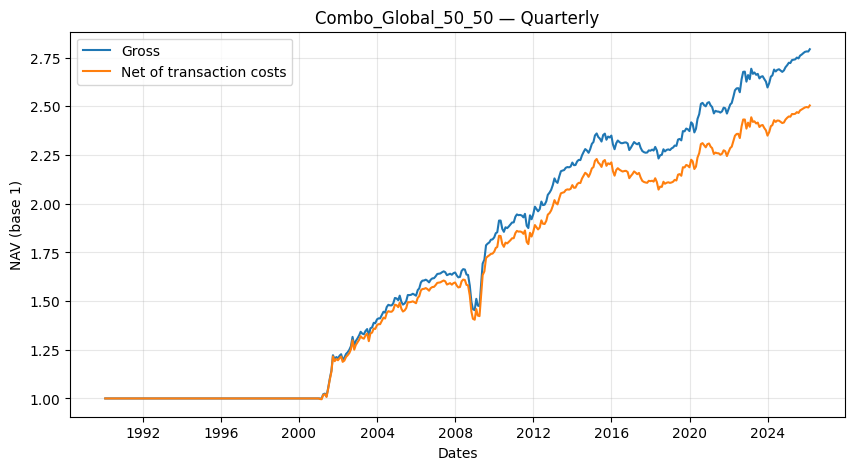

In [5]:
# Graphique simple pour contrôle
plt.figure(figsize=(10, 5))
plt.plot(nav_gross.index, nav_gross, label="Gross")
plt.plot(nav_net.index, nav_net, label="Net of transaction costs")
plt.title("Combo_Global_50_50 — Quarterly")
plt.ylabel("NAV (base 1)")
plt.xlabel("Dates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Pour l’intégration cross-asset, la série à utiliser est `net_returns`. Elle correspond au rendement mensuel net de coûts de la sleeve fixed income. Les poids mensuels peuvent être utilisés si l’équipe d’intégration préfère agréger les sleeves par expositions plutôt que par séries de rendement.

In [6]:
import numpy as np
# Conversion du rendement arithmétique net en log return
log_net_returns = np.log(1 + net_returns)

# Export pour l'intégration cross-asset
pd.DataFrame({"Dates": log_net_returns.index, "fi_log_return_net": log_net_returns.values}).to_excel("fi_combo_global_quarterly_log_returns.xlsx", index=False)

pd.DataFrame({"Dates": gross_returns.index, "fi_combo_global_quarterly_gross_return": gross_returns.values}).to_excel(
    "fi_combo_global_quarterly_gross_returns.xlsx", index=False
)

weights_export = weights.copy()
weights_export.insert(0, "Dates", weights_export.index)
weights_export.to_excel("fi_combo_global_quarterly_weights.xlsx", index=False)

summary_export = summary.reset_index()
summary_export.to_excel("fi_combo_global_quarterly_summary.xlsx", index=False)

print("Exports créés :")
print("- fi_combo_global_quarterly_net_returns.xlsx")
print("- fi_combo_global_quarterly_gross_returns.xlsx")
print("- fi_combo_global_quarterly_weights.xlsx")
print("- fi_combo_global_quarterly_summary.xlsx")


Exports créés :
- fi_combo_global_quarterly_net_returns.xlsx
- fi_combo_global_quarterly_gross_returns.xlsx
- fi_combo_global_quarterly_weights.xlsx
- fi_combo_global_quarterly_summary.xlsx
